## Extracción de Caracteristicas para los sistemas trifasicos


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis, entropy
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob
import nolds
from joblib import Parallel, delayed
import algoritmos_deteccion as ad
import random
import shutil
from scipy.fft import fft

## Segmentación para sistemas trifasicos

In [29]:
def _setup_academic_style():
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5
    

def visualizar_segmentacion_completa(va, vb, vc, fs, signal_id):
    """
    Genera un gráfico de 3 paneles para visualizar el proceso de segmentación.
    """
    _setup_academic_style()
    
    t = np.arange(len(va)) / fs

    # --- Generar máscaras para visualización (usando Fase A como referencia) ---
    mascara_rms = ad.generar_mascara_rms(va, fs)
    mascara_swt = ad.generar_mascara_swt(va)
    mascara_hilbert = ad.generar_mascara_hilbert(va)

    # --- Encontrar el segmento final trifásico ---
    t_inicio_idx, t_fin_idx = ad.encontrar_intervalo_global(va, vb, vc, fs)

    # --- Crear figura de 3 paneles ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'Proceso de Segmentación para: {signal_id}', fontsize=20)

    # Panel 1: Señal Trifásica Original
    axes[0].plot(t, va, label='Fase A')
    axes[0].plot(t, vb, label='Fase B')
    axes[0].plot(t, vc, label='Fase C')
    axes[0].set_ylabel('Amplitud (p.u.)')
    axes[0].set_title('Señal Original')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle=':')

    # Panel 2: Máscaras de Detección (sobre Fase A)
    axes[1].plot(t, va, color='gray', alpha=0.5, label='Fase A (ref.)')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_rms, alpha=0.4, label='Máscara RMS', step='post')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_hilbert, alpha=0.4, label='Máscara Hilbert', step='post')
    axes[1].fill_between(t, -1.5, 1.5, where=mascara_swt, alpha=0.4, label='Máscara SWT', step='post')
    axes[1].set_ylabel('Detección')
    axes[1].set_title('Máscaras Individuales (sobre Fase A)')
    axes[1].set_ylim(-1.5, 1.5)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':')

    # Panel 3: Resultado de la Segmentación
    axes[2].plot(t, va, color='gray', alpha=0.3)
    axes[2].plot(t, vb, color='gray', alpha=0.3)
    axes[2].plot(t, vc, color='gray', alpha=0.3)
    if t_inicio_idx is not None and t_fin_idx is not None:
        axes[2].axvspan(t[t_inicio_idx], t[t_fin_idx], color='red', alpha=0.2, label='Segmento Global')
        t_segmento = t[t_inicio_idx:t_fin_idx]
        axes[2].plot(t_segmento, va[t_inicio_idx:t_fin_idx], color='blue', label='Fase A Seg.')
        axes[2].plot(t_segmento, vb[t_inicio_idx:t_fin_idx], color='orange', label='Fase B Seg.')
        axes[2].plot(t_segmento, vc[t_inicio_idx:t_fin_idx], color='green', label='Fase C Seg.')
    axes[2].set_xlabel('Tiempo (s)')
    axes[2].set_ylabel('Amplitud (p.u.)')
    axes[2].set_title('Resultado de Segmentación Trifásica')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, linestyle=':')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ==============================================================================
file_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_Completo_2.parquet"
signal_id_prueba = "Sag_A_clean_0010"
fs = 7200 # frecuencia de muestreo

print(f"Buscando y cargando eficientemente la señal: {signal_id_prueba}...")

# 2. Carga SOLO la señal necesaria usando filtros (evita error de memoria)
try:
    filters = [('signal_id', '=', signal_id_prueba)]
    una_señal_df = pd.read_parquet(file_path, filters=filters)
except Exception as e:
    print(f"No se pudo cargar la señal. Error: {e}")
    # Salir si el DataFrame no se pudo crear
    exit()

# 3. El resto de tu código funciona igual
va_original = una_señal_df['Phase_A'].values
vb_original = una_señal_df['Phase_B'].values
vc_original = una_señal_df['Phase_C'].values

print(f"Procesando señal: {signal_id_prueba}")
print(f"Longitud original de la señal: {len(va_original)} muestras")

# Llama a la nueva función orquestadora
# (Asegúrate de que 'ad' esté importado si tus funciones están en otro archivo)
va_seg, vb_seg, vc_seg = ad.segmentar_evento_trifasico(va_original, vb_original, vc_original, fs)

print(f"Longitud de la señal segmentada: {len(va_seg)} muestras")

#visualizar_segmentacion_completa(va_original, vb_original, vc_original, fs, signal_id_prueba)

Buscando y cargando eficientemente la señal: Sag_A_clean_0010...
Procesando señal: Sag_A_clean_0010
Longitud original de la señal: 7200 muestras
Longitud de la señal segmentada: 794 muestras


## Caracteristicas

In [ ]:
import numpy as np
import pywt
from scipy.stats import kurtosis
import pandas as pd
import random
# =============================================================================
# SECCIÓN 1: FUNCIÓN DE TRANSFORMACIÓN (ACTUALIZADA)
# =============================================================================

def calcular_transformaciones_trifasicas(va, vb, vc):
    """
    Calcula las Componentes Simétricas (V0, V1, V2) y la Transformada de Clarke.
    """
    a = np.exp(1j * 2 * np.pi / 3)
    va_c, vb_c, vc_c = va.astype(complex), vb.astype(complex), vc.astype(complex)
    
    # --- CÁLCULO AÑADIDO ---
    v0 = (1/3) * (va_c + vb_c + vc_c)
    
    v1 = (1/3) * (va_c + a * vb_c + a**2 * vc_c)
    v2 = (1/3) * (va_c + a**2 * vb_c + a * vc_c)
    
    v_alpha = (2/3) * (va - 0.5 * vb - 0.5 * vc)
    v_beta = (2/3) * (np.sqrt(3)/2 * vb - np.sqrt(3)/2 * vc)
    
    # --- RETURN ACTUALIZADO ---
    return v0, v1, v2, v_alpha, v_beta

# =============================================================================
# SECCIÓN 2: FUNCIÓN DE EXTRACCIÓN DE CARACTERÍSTICAS (ACTUALIZADA)
# =============================================================================
def extraer_caracteristicas_trifasicas(va_seg, vb_seg, vc_seg, fs, rms_nominal_val):
    """
    Versión definitiva que fusiona las características más potentes para resolver
    las confusiones específicas del dataset generado.
    """
    v0, v1, v2, _, _ = calcular_transformaciones_trifasicas(va_seg, vb_seg, vc_seg)
    v0_mag, v1_mag, v2_mag = np.abs(v0), np.abs(v1), np.abs(v2)
    features = {}
    
    # --- Características de Magnitud Fundamentales ---
    rms_v0_temp = np.sqrt(np.mean(v0_mag**2))
    rms_v1_temp = np.sqrt(np.mean(v1_mag**2))
    rms_v2_temp = np.sqrt(np.mean(v2_mag**2))
    features['rms_V0mag'] = rms_v0_temp
    features['rms_V1mag'] = rms_v1_temp
    features['rms_V2mag'] = rms_v2_temp
    features['profundidad_V1mag'] = rms_v1_temp / rms_nominal_val if rms_nominal_val > 1e-6 else 0.0
    features['vuf'] = rms_v2_temp / rms_v1_temp if rms_v1_temp > 1e-6 else 0.0


    rms_a = np.sqrt(np.mean(va_seg**2))
    rms_b = np.sqrt(np.mean(vb_seg**2))
    rms_c = np.sqrt(np.mean(vc_seg**2))
    
    # Experto 1: Simetría Geométrica
    rms_sorted = np.sort([rms_a, rms_b, rms_c])
    rms_min, rms_mid, rms_max = rms_sorted[0], rms_sorted[1], rms_sorted[2]
    denominator = rms_max - rms_min
    features['rms_asymmetry_ratio'] = (rms_mid - rms_min) / denominator if denominator > 1e-6 else 0.0

    # Experto 2: Simetría de Energía
    features['unbalance_index'] = (rms_v0_temp + rms_v2_temp) / rms_v1_temp if rms_v1_temp > 1e-6 else 0.0
    
    # Experto 3: Simetría de Forma
    if len(va_seg) > 1:
        corr_matrix = np.corrcoef([va_seg, vb_seg, vc_seg])
        corr_values = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
        features['min_corr_abc'] = np.min(corr_values) if len(corr_values) > 0 else 1.0
    else:
        features['min_corr_abc'] = 1.0

    # --- Para distinguir fallas con y sin tierra (asumiendo que corriges C vs E) ---
    if pywt.dwt_max_level(len(v0_mag), 'db4') > 0:
        coeffs_v0 = pywt.wavedec(v0_mag, 'db4', level=1)
        features['wavelet_energia_cD1_V0mag'] = np.sum(coeffs_v0[1]**2)
    else:
        features['wavelet_energia_cD1_V0mag'] = 0.0

    # --- Características Auxiliares de Contexto ---
    umbral_sag = rms_nominal_val * 0.90 
    features['fase_afectada_A'] = 1 if rms_a < umbral_sag else 0
    features['fase_afectada_B'] = 1 if rms_b < umbral_sag else 0
    features['fase_afectada_C'] = 1 if rms_c < umbral_sag else 0
    fases_afectadas_count = features['fase_afectada_A'] + features['fase_afectada_B'] + features['fase_afectada_C']
    features['fase_afectada_N'] = 1 if fases_afectadas_count == 0 else 0
            
    return features

def procesar_una_señal(signal_df, meta_order): # <--- 1. AÑADIR ARGUMENTO
    """
    Versión definitiva que fuerza el orden de las columnas de salida
    para que coincida con el meta de Dask.
    """
    etiqueta = signal_df['etiqueta'].iloc[0]
    va_orig, vb_orig, vc_orig = signal_df['Phase_A'].values, signal_df['Phase_B'].values, signal_df['Phase_C'].values
    fs = 7200
    
    # --- Lógica de segmentación (sin cambios) ---
    muestras_ciclo = int(fs / 60)
    rms_nominal_val = np.sqrt(np.mean(va_orig[:5*muestras_ciclo]**2))
    
    # Asumo que 'ad' está importado y funciona
    t_inicio, t_fin = ad.encontrar_intervalo_global(va_orig, vb_orig, vc_orig, fs)
    
    if t_inicio is not None and t_fin is not None:
        va_seg, vb_seg, vc_seg = va_orig[t_inicio:t_fin], vb_orig[t_inicio:t_fin], vc_orig[t_inicio:t_fin]
    else:
        longitud_segmento = 15 * muestras_ciclo
        if len(va_orig) > longitud_segmento:
            inicio_aleatorio = random.randint(0, len(va_orig) - longitud_segmento)
            fin_aleatorio = inicio_aleatorio + longitud_segmento
            va_seg, vb_seg, vc_seg = va_orig[inicio_aleatorio:fin_aleatorio], vb_orig[inicio_aleatorio:fin_aleatorio], vc_orig[inicio_aleatorio:fin_aleatorio]
        else:
            va_seg, vb_seg, vc_seg = va_orig, vb_orig, vc_orig

    if len(va_seg) == 0:
        va_seg, vb_seg, vc_seg = va_orig, vb_orig, vc_orig
            
    # --- Creación de características (sin cambios) ---
    fila_final = extraer_caracteristicas_trifasicas(va_seg, vb_seg, vc_seg, fs, rms_nominal_val)
    fila_final['etiqueta'] = etiqueta
    
    # --- 2. LA MAGIA: FORZAR EL ORDEN CORRECTO ---
    # Convierte a Serie de Pandas y la reordena para que coincida EXACTAMENTE con meta
    result_series = pd.Series(fila_final).reindex(meta_order)
    
    result_series.name = signal_df.name
    return result_series

In [31]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import time
import os
import glob
import shutil

# Asumo que tus funciones 'procesar_una_señal' y 'extraer_caracteristicas'
# están definidas en otro lugar y son importadas correctamente.

if __name__ == '__main__':
    start_time = time.time()

    # Rutas de entrada y salida
    input_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet"
    output_path = "Dataset_Caracteristicas_Trifasico_5.parquet"
    temp_dir = "temp_caracteristicas"

    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    print("Obteniendo la lista de clases del dataset...")
    clases_de_fallas = pd.read_parquet(input_path, columns=['etiqueta'])['etiqueta'].unique()
    print(f"Clases encontradas: {clases_de_fallas}")

    # --- META CORREGIDO ---
    # Este diccionario ahora coincide con la salida de tu función de extracción
    meta = {
        'rms_V0mag': 'float64', 'rms_V1mag': 'float64', 'rms_V2mag': 'float64',
        'profundidad_V1mag': 'float64', 'vuf': 'float64',
        'rms_asymmetry_ratio': 'float64', 'unbalance_index': 'float64',
        'min_corr_abc': 'float64', 'wavelet_energia_cD1_V0mag': 'float64',
        'fase_afectada_A': 'int64', 'fase_afectada_B': 'int64', 'fase_afectada_C': 'int64',
        'fase_afectada_N': 'int64', 'etiqueta': 'object'
    }
    # Procesar una clase a la vez para controlar el uso de memoria
    for clase in clases_de_fallas:
        print(f"\n--- Iniciando procesamiento para la clase: {clase} ---")
        ddf_clase = dd.read_parquet(input_path, filters=[('etiqueta', '=', clase)])
        
        with ProgressBar():
            # AÑADE EL ARGUMENTO 'meta_order' AQUÍ
            caracteristicas_df = ddf_clase.groupby('signal_id').apply(
                procesar_una_señal, 
                meta=meta,
                meta_order=list(meta.keys()) # <--- ¡ESTA ES LA CORRECCIÓN!
            ).compute(scheduler='threads')
        
        temp_file_path = os.path.join(temp_dir, f"caracteristicas_{clase}.parquet")
        caracteristicas_df.to_parquet(temp_file_path, index=True)
        print(f"Características para la clase '{clase}' guardadas en: {temp_file_path}")

    # Unir todos los archivos temporales en el dataset final
    print("\n--- Uniendo todos los archivos de características ---")
    ddf_final = dd.read_parquet(os.path.join(temp_dir, "*.parquet"))
    
    with ProgressBar():
        ddf_final.to_parquet(output_path, write_index=True)

    print(f"\nProcesamiento completado.")
    end_time = time.time()
    print(f"¡Proceso completo en {(end_time - start_time) / 60:.2f} minutos!")
    print(f"Dataset de características final guardado en: {output_path}")

    # Limpiar el directorio temporal
    print("Limpiando directorio temporal...")
    shutil.rmtree(temp_dir)
    print("Directorio temporal eliminado.")

Obteniendo la lista de clases del dataset...
Clases encontradas: ['Normal' 'Sag_A' 'Sag_B' 'Sag_C' 'Sag_D' 'Sag_E' 'Sag_F' 'Sag_G']

--- Iniciando procesamiento para la clase: Normal ---
[########################################] | 100% Completed | 39.94 s
Características para la clase 'Normal' guardadas en: temp_caracteristicas\caracteristicas_Normal.parquet

--- Iniciando procesamiento para la clase: Sag_A ---
[########################################] | 100% Completed | 40.00 s
Características para la clase 'Sag_A' guardadas en: temp_caracteristicas\caracteristicas_Sag_A.parquet

--- Iniciando procesamiento para la clase: Sag_B ---
[########################################] | 100% Completed | 43.02 s
Características para la clase 'Sag_B' guardadas en: temp_caracteristicas\caracteristicas_Sag_B.parquet

--- Iniciando procesamiento para la clase: Sag_C ---
[########################################] | 100% Completed | 41.19 s
Características para la clase 'Sag_C' guardadas en: temp_car

Cargando el dataset de características...
Dataset cargado. Columnas de características: ['rms_V0mag', 'rms_V1mag', 'rms_V2mag', 'profundidad_V1mag', 'vuf', 'rms_asymmetry_ratio', 'unbalance_index', 'min_corr_abc', 'wavelet_energia_cD1_V0mag', 'fase_afectada_A', 'fase_afectada_B', 'fase_afectada_C', 'fase_afectada_N']

Preprocesando características...
Se escalaron 13 características numéricas.

Calculando la proyección t-SNE... (esto puede tardar unos minutos)
Generando el gráfico...


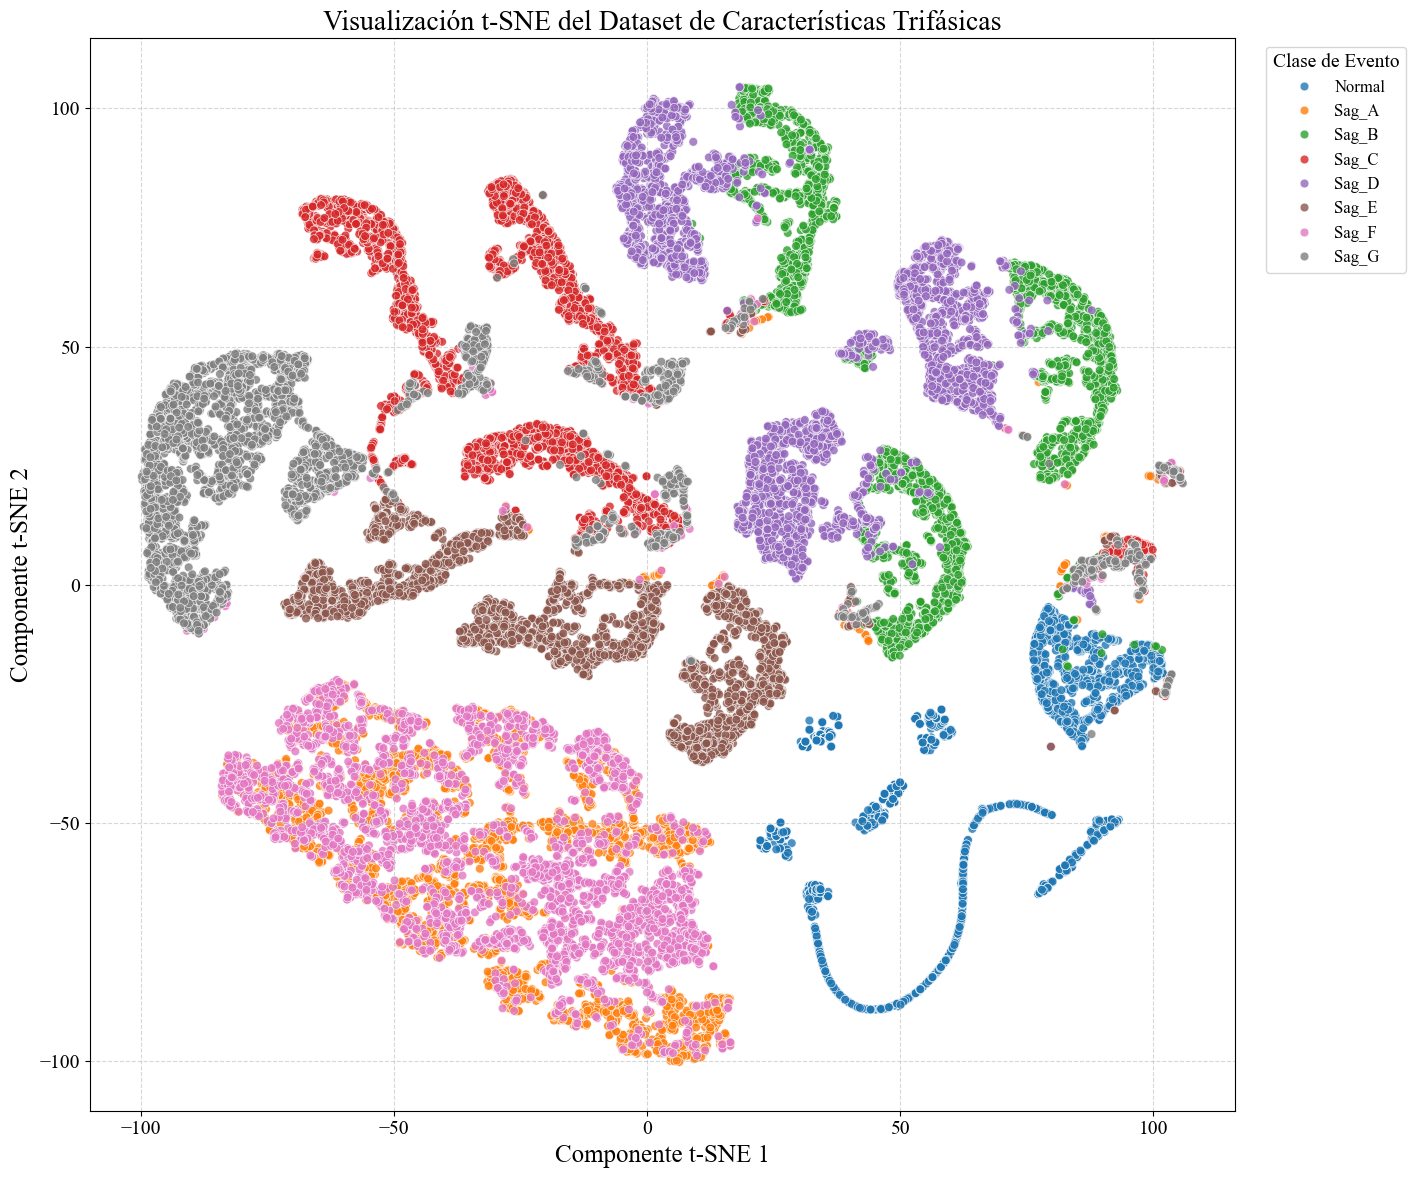

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['axes.titlesize'] = 20
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5

# --- 1. Cargar y preparar los datos ---
print("Cargando el dataset de características...")
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet"
df = pd.read_parquet(data_path)

X = df.drop('etiqueta', axis=1)
y = df['etiqueta']
print("Dataset cargado. Columnas de características:", X.columns.tolist())

# --- 2. Escalar las características (ya son todas numéricas) ---
print("\nPreprocesando características...")
scaler = StandardScaler()
# Ahora X_final_para_tsne es simplemente el resultado de escalar X
X_final_para_tsne = scaler.fit_transform(X) 
print(f"Se escalaron {X_final_para_tsne.shape[1]} características numéricas.")

# --- 3. Cálculo de t-SNE ---
print("\nCalculando la proyección t-SNE... (esto puede tardar unos minutos)")
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_final_para_tsne)

# Crear un DataFrame para la visualización
tsne_df = pd.DataFrame(data=X_tsne, columns=['Componente 1', 'Componente 2'])
tsne_df['etiqueta'] = y.values # Usar .values para evitar problemas de índice

# --- 4. Graficar ---
print("Generando el gráfico...")
_setup_academic_style()
plt.figure(figsize=(16, 12))

ax = sns.scatterplot(
    x="Componente 1", y="Componente 2",
    hue="etiqueta",
    palette=sns.color_palette("tab10", len(df['etiqueta'].unique())),
    data=tsne_df,
    legend="full",
    alpha=0.8,
    s=40
)

plt.title('Visualización t-SNE del Dataset de Características Trifásicas')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clase de Evento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.9, 1])
# Descomenta la siguiente línea si quieres guardar la imagen
# plt.savefig("tsne_caracteristicas_trifasicas_final.svg", format='svg', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- 1. Cargar y preparar los datos ---
print("Cargando el dataset de características...")
# --- CAMBIO 1: Apuntar al nuevo dataset con características numéricas ---
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_4.parquet"
df = pd.read_parquet(data_path)

# Separa el DataFrame en características (X) y la etiqueta (y)
X = df.drop('etiqueta', axis=1)
y = df['etiqueta']
print("Dataset cargado. Columnas de características:", X.columns.tolist())


# --- 2. Escalar todas las características ---
# --- CAMBIO 2: Lógica de preprocesamiento simplificada ---
# Como todas las columnas en X ahora son numéricas, podemos escalarlas directamente.
print("\nEscalando características...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Se escalaron {X_scaled.shape[1]} características.")


# --- 3. Bucle para probar y graficar diferentes valores de perplejidad ---
perplexity_values = [10, 30, 60]

# Crea una figura de Matplotlib con subplots para cada gráfico
fig, axes = plt.subplots(1, len(perplexity_values), figsize=(30, 8)) 

for i, perplexity in enumerate(perplexity_values):
    print(f"Calculando t-SNE para perplexity = {perplexity}...")
    
    # Inicializa y aplica el algoritmo t-SNE
    # --- CAMBIO 3: Usar el set de datos escalado completo ---
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Crea un DataFrame con los resultados para facilitar la graficación con Seaborn
    tsne_df = pd.DataFrame(data=X_tsne, columns=['Componente 1', 'Componente 2'])
    tsne_df['etiqueta'] = y.values
    
    # Selecciona el subplot correspondiente
    ax = axes[i]
    
    # Crea el gráfico de dispersión con Seaborn
    sns.scatterplot(
        x="Componente 1", y="Componente 2",
        hue="etiqueta",
        palette=sns.color_palette("tab10", len(df['etiqueta'].unique())),
        data=tsne_df,
        legend=(i == len(perplexity_values) - 1),
        ax=ax
    )
    
    # Configuración de la apariencia del gráfico
    ax.set_title(f'Perplejidad = {perplexity}', fontsize=24)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlabel("Componente 1", fontsize=24)
    ax.set_ylabel("Componente 2", fontsize=24)
    ax.tick_params(axis='both', which='major', labelsize=24)

# --- 4. Ajustar y mostrar la leyenda en el último gráfico ---
if len(perplexity_values) > 0:
    axes[-1].legend(
        title='Clase de Evento', 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left',
        fontsize=20,
        title_fontsize=22
    )

# Ajusta el layout para que todo encaje bien
plt.tight_layout()

# Opcional: Guarda la figura en alta calidad
# plt.savefig("tsne_comparacion_perplejidad_actualizado.svg", format='svg', dpi=300, bbox_inches='tight')

# Muestra el gráfico
plt.show()